In [25]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1.1

### a)

In [26]:
from typing import Callable, Final

N: int = 8
FUNCTION: Callable[[float], float] = \
        lambda x: x

def box_rule(N: int,
        f: Callable[[float], float])-> float:
    h = 1 / N
    x_i = np.linspace(0, 1, N + 1)[:-1]
    return np.sum(f(x_i) * h)

def trapezoidal_rule(N: int,
        f: Callable[[float], float])-> float:
    h = 1 / N
    x_i = f(np.linspace(0, 1, N + 1))
    return np.sum(x_i[:-1] + x_i[1:]) * h / 2


print(box_rule(N, FUNCTION))
print(trapezoidal_rule(N, FUNCTION))

0.4375
0.5


### b)

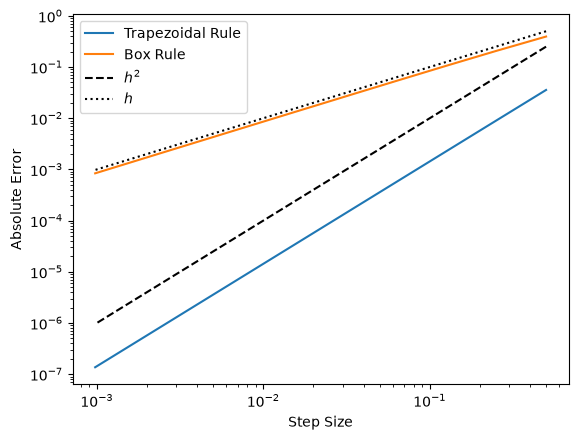

In [40]:
import matplotlib


FUNCTION: Final[Callable[[float], float]] = \
        lambda x: np.exp(x)
N = np.array([2**(i + 1) for i in range(0, 10)])


err = lambda n, f: np.e - 1 - f(n, FUNCTION)
errors_trap = np.array([err(n, trapezoidal_rule)
                    for n in N])
errors_box = np.array([err(n, box_rule)
                    for n in N])

h = 1 / N
matplotlib.pyplot.loglog(h, np.abs(errors_trap), label='Trapezoidal Rule')
matplotlib.pyplot.loglog(h, np.abs(errors_box), label='Box Rule')
matplotlib.pyplot.xlabel('Step Size')
matplotlib.pyplot.ylabel('Absolute Error')
plt.loglog(h, h**2, 'k--', label=r'$h^2$')
plt.loglog(h, h,    'k:',  label=r'$h$')
matplotlib.pyplot.legend()
matplotlib.pyplot.show()

**Does the true error behave like $Ch^2$?**

Assume $err = Ch^2$, $C$ – const, $h = 2^{-i-1}$.

On the log-log plot:
- x-axis: $\log h = -(i+1)\log 2 = -i\log 2 + C'$ – linear in $i$
- y-axis: $\log|err| = \log C + 2\log h = -2i\log 2 + C''$ – linear in $i$

$\Rightarrow y = 2x + C'''$: a straight line with slope 2.
The constant $C$ only shifts the line up/down, it does not change the slope.

Trapezoidal rule: the error line is parallel to the reference line $h^2$
→ yes, $err \sim Ch^2$.

Box rule: same argument gives $y = x + C''''$; the error line is parallel
to the reference line $h$ → $err \sim Ch$, so the box rule converges
slower and its error is larger for all $h$.